In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv
from IPython.display import Markdown,display
from pydantic import BaseModel,Field
from typing import Literal

In [2]:
load_dotenv(override=True)

True

In [3]:
llm=ChatMistralAI(
    model="open-mistral-7b",
    temperature=0
)

In [4]:
class UniversityState(BaseModel):
    question: str
    department: Literal["admission", "hostel", "financial"] | None = None
    response: str | None = None

In [5]:
class RouteDecision(BaseModel):
    department: Literal["admission", "hostel", "financial"] = Field(
        description="The department that should handle the user's question."
    )

In [6]:
structured_llm = llm.with_structured_output(RouteDecision)

In [7]:
def manager_node(state: UniversityState):
    prompt = f"""
You are the manager of a university help system.

Classify the user's question into exactly one department:

- admission: admission requirements, applications, eligibility, programs
- hostel: hostel rooms, accommodation, hostel rules, hostel fees
- financial: tuition fees, scholarships, payments, financial issues

User question:
{state.question}
"""

    result = structured_llm.invoke(prompt)

    return {
        "department": result.department
    }

In [8]:
admission_knowledge = """
Muhammad Haris University Admission Knowledge Base:

- Students can apply for undergraduate programs.
- Applicants must have completed intermediate education.
- The minimum required percentage is 50%.
- Students must submit their application online.
- Required documents include academic certificates and identification documents.
"""
hostel_knowledge = """
Muhammad Haris University Hostel Knowledge Base:

- The university provides hostel accommodation for students.
- Students must apply for hostel accommodation.
- Hostel fees are paid per semester.
- Hostel rooms are subject to availability.
- Students must follow university hostel rules and regulations.
"""
financial_knowledge = """
Muhammad Haris University Financial Knowledge Base:

- Tuition fees are paid per semester.
- Scholarships are available for eligible students.
- Students can contact the finance office for fee-related issues.
- Financial information may vary depending on the academic program.
"""

In [9]:
def admission_node(state: UniversityState):
    prompt = f"""
You are the Admission Specialist for Muhammad Haris University.

Answer the user's question using ONLY the knowledge base below.

Knowledge Base:
{admission_knowledge}

User Question:
{state.question}

If the information is not available in the knowledge base, clearly say that
the information is not available in the knowledge base.
"""

    result = llm.invoke(prompt)

    return {
        "response": result.content
    }

In [10]:
def hostel_node(state: UniversityState):
    prompt = f"""
You are the Hostel Specialist for Muhammad Haris University.

Answer the user's question using ONLY the knowledge base below.

Knowledge Base:
{hostel_knowledge}

User Question:
{state.question}

If the information is not available in the knowledge base, clearly say that
the information is not available in the knowledge base.
"""

    result = llm.invoke(prompt)

    return {
        "response": result.content
    }

In [11]:
def financial_node(state: UniversityState):
    prompt = f"""
You are the Financial Specialist for Muhammad Haris University.

Answer the user's question using ONLY the knowledge base below.

Knowledge Base:
{financial_knowledge}

User Question:
{state.question}

If the information is not available in the knowledge base, clearly say that
the information is not available in the knowledge base.
"""

    result = llm.invoke(prompt)

    return {
        "response": result.content
    }

In [12]:
state = UniversityState(
    question="Are scholarships available?"
)

result = financial_node(state)

print(result["response"])

Yes, scholarships are available for eligible students at Muhammad Haris University.


In [13]:
def route_info(state: UniversityState):
    if state.department == "admission":
        return "admission"

    elif state.department == "hostel":
        return "hostel"

    elif state.department == "financial":
        return "financial"

In [14]:
graph_builder = StateGraph(UniversityState)

In [15]:
graph_builder.add_node("manager", manager_node)
graph_builder.add_node("admission", admission_node)
graph_builder.add_node("hostel", hostel_node)
graph_builder.add_node("financial", financial_node)

In [16]:
graph_builder.add_edge(START, "manager")


In [17]:
graph_builder.add_conditional_edges(
    "manager",
    route_info,
    {
        "admission": "admission",
        "hostel": "hostel",
        "financial": "financial",
    }
)

In [18]:
graph_builder.add_edge("admission", END)
graph_builder.add_edge("hostel", END)
graph_builder.add_edge("financial", END)

In [19]:
graph = graph_builder.compile()

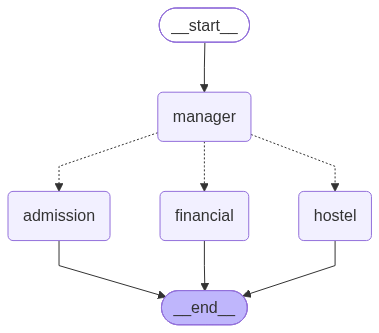

In [20]:
graph

In [21]:
initial_state = UniversityState(
    question="What percentage is required for admission?"
)

In [22]:
result = graph.invoke(initial_state)


In [23]:
display(Markdown(result["department"]))
display(Markdown(result["response"]))

admission

The minimum required percentage for admission to Muhammad Haris University is **50%**.